<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%206.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분류

## 분류의 개요



*   **지도학습**은 레이블(Label), 즉 명시적인 정답이 있는 데이터가 주어진 상태에세 학습하는 머신러닝 방식이다. 지도학습의 대표적인 유형인 **분류(Classification)**는 학습 데이터로 주어진 데이터의 피처와 레이블값(결정 값, 클래스 값)을 머신러닝 알고리즘으로 학습해 모델을 생성하고, 이렇게 생성된 모델에 새로운 데이터 값이 주어졌을 때 미지의 레이블 값을 예측하는 것이다.
*   분류는 다양한 머신러닝 알고리즘으로 구현할 수 있는데, 이 장에서는 **앙상블 방법(Ensemble Method)**를 집중적으로 다룬다. 앙상블은 정형 데이터의 예측 분석 영역에서의 매우 높은 예측 성능으로 많은 분석가들과 데이터 과학자들에게 애용되고 있다. 앙상블은 서로 다른, 또는 같은 알고리즘을 단순히 결합한 형태도 있으나 일반적으로는 **배깅(Bagging)**과 **부스팅(Boosting)** 방식으로 나뉜다. 배깅 방식의 대표인 랜덤 포레스트(Random Forest)는 뛰어난 예측 성능, 상대적으로 빠른 수행 시간, 유연성 등으로 많은 분석가가 애용하는 알고리즘이다. 하지만 근래의 앙상블 방법은 부스팅 방식으로 계속해서 발전 중이다. 부스팅의 효시라고 할 수 있는 그래디언트 부스팅(Gradient Boosting)의 경우 뛰어난 예측 성능을 가지고 있지만, 수행 시간이 너무 오래 걸리는 단점으로 인해 최적화 모델 튜닝이 어려웠다. 하지만 XgBoost(eXtra Gradient Boost)와 LightGBM 등 기존 그래디언트 부스팅의 예측 성능을 한 단계 발전시키면서도 수행 시간을 단축시킨 알고리즘이 계속 등장하면서 정형 데이터의 분류 영역에서 가장 활용도가 높은 알고리즘으로 자리매김했다.
*   앙상블은 서로 다른 또는 같은 알고리즘을 결합한다고 했는데, 대부분은 동일한 알고리즘을 결합한다. 앙상블의 기본 알고리즘으로 일반적으로 결정 트리를 사용한다. 결정 트리는 매우 쉽고 유연하게 적용될 수 있는 알고리즘이다. 또, 데이터의 스케일링이나 정규화 등의 사전 가공의 영향이 매우 적다. 하지만 예측 성능을 향상시키기 위해 복잡한 규칙 구조를 가져야 하며, 이로 인해 과적합이 발생해 반대로 예측 성능이 저하될 수도 있다는 단점이 있다. 하지만 이러한 단점이 오히려 앙상블 기법에서는 장점으로 작용한다. 앙상블은 매우 많은 개수의 예측 성능이 상대적으로 떨어지는 학습 알고리즘을 결합해 확률적 보완과 오류가 발생한 부분에 대한 가중치를 계속 업데이트하면서 예측 성능을 향상시키는데, 결정 트리가 이 약한 학습 알고리즘이 되기 때문이다.



## 결정 트리(Decision Tree)



*   결정 트리(Decision Tree)는 데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리(Tree) 기반의 분류 규칙을 만드는 알고리즘으로, ML 알고리즘 중 직관적으로 이해하기 쉬운 알고리즘이다. 일반적으로 규칙을 가장 쉽게 표현하는 방법은 if/else 기반으로 나타내는 것인데, 쉽게 생각하면 스무고개 게임과 유사하며 룰 기반의 프로그램에 적용되는 if, else를 자동으로 찾아내 예측을 위한 규칙을 만드는 알고리즘으로 이해할 수 있다. 따라서 데이터의 어떤 기준을 바탕으로 규칙을 만들어야 가장 효율적인 분류가 될 것인가가 알고리즘의 성능을 크게 좌우한다.
*   결정 트리에서 규칙 노드(Decision Node)는 규칙 조건이고, 리프 노드(Leaf Node)는 결정된 클래스 값이다. 새로운 규칙 조건마다 서브 트리(Sub Tree)가 생성되다. 데이터 세트가 피처가 있고 이러한 피처가 결합해 규칙 조건을 만들 때마다 규칙 노드가 만들어진다.
*   *하지만 많은 규칙이 있다는 것은 곧 분류를 결정하는 방식이 더욱 복잡해진다는 뜻이고, 이는 곧 과적합으로 이어지기 쉽다. 즉, 트리의 깊이(depth)가 깊어질수록 결정 트리의 예측 성능이 저하될 가능성이 높다.* 가능한 한 적은 결정 노드로 높은 정확도를 가지기 위해서는, 데이터를 분류할 때 최대한 많은 데이터 세트가 해당 분류에 속할 수 있도록 결정 노드의 규칙이 정해져야 한다. 이를 위해 어떻게 트리를 분할할 것인가가 중요한데, 최대한 균일한 데이터 세트를 구성할 수 있도록 분할하는 것이 필요하다. 데이터 세트의 균일도는 데이터를 구분하는 데 필요한 정보의 양에 영향을 미친다.
*   결정 노드는 정보 균일도가 높은 데이터 세트를 먼저 선택할 수 있도록 규칙 조건을 만든다. 즉, 정보 균일도가 데이터 세트로 쪼개질 수 있도록 조건을 찾아 서브 데이터 세트를 만들고, 다시 이 서브 데이터 세트에서 균일도가 높은 자식 데이터 세트를 쪼개는 방식을 자식 트리로 내려가면서 반복하는 방식으로 데이터 값을 예측하게 된다.
*   정보의 균일도를 측정하는 대표적인 방법은 엔트로피를 이용한 정보 이득(Information Gain) 지수와 지니 계수가 있다. 정보 이득은 엔트로피라는 개념을 기반으로 한다. **엔트로피**는 주어진 데이터 집합의 혼잡도를 의마하며, 서로 다른 값이 섞여 있으면 엔트로피가 높고, 같은 값이 섞여 있을수록 엔트로피는 낮다. **정보 이득 지수**는 1에서 엔트로피 지수를 뺀 갓이다. 결정 트리는 이 정보 이득 지수로 분할 기준을 정한다. 즉, 정보 이득이 높은 속성을 기준으로 분할한다. **지니 계수**는 원래 경제학에서 불평등 지수를 나타낼 때 사용하는 계수인데, 머신러닝에 적용될 때는 지니 계수가 낮을수록 데이터 균일도가 높은 것으로 해석해 지니 계수가 낮은 속성을 기준으로 분할한다.
*   결정 트리 알고리즘을 사이킷런에서 구현한 DecisionTreeClassifier는 기본으로 지니 계수를 이용해 데이터 세트를 분할한다. 결정 트리의 일반적인 알고리즘은 데이터 세트를 분할하는 데 가장 좋은 조건, 즉 정보 이득이 높거나 지니 계수가 낮은 조건을 찾아 자식 트리 노드에 걸쳐 반복적으로 분할한 뒤, 데이터가 모두 특정 분류에 속하게 되면 분할을 멈추고 분류를 결정한다.







### 결정 트리 모델의 특징


*   결정 트리의 가장 큰 장점은 정보의 균일도라는 룰을 기반으로 하고 있어, 알고리즘이 쉽고 직관적이라는 점이다. 이에 기반에 어떻게 규칙 노드와 리프 노드가 만들어지는지 알 수 있고, 시각화로 표현까지 할 수 있다. 또, 정보의 균일도만 신경 쓰면 되므로 특별한 경우를 제외하고는 각 피처의 스케일링과 정규화 같은 전처리 작업이 필요 없다.
*   반면 *결정 트리의 가장 큰 단점은 과적합으로 정확도가 떨어진다는 점이다.* 피처 정보의 균일도에 따른 룰 규칙으로 서브 트리를 계속 만들다 보면 피처가 많고 균일도가 다양하게 존재할수록 트리의 깊이가 커지고 복잡해질 수밖에 없다. 복잡한 학습 모델은 결국 실제 상황(테스트 데이터 세트)에 유연하게 대처할 수 없어 예측 성능이 떨어질 수밖에 없다. 이 때 트리의 크기를 사전에 제한하는 튜닝이 필요하다.

## 결정 트리 파라미터
*   사이킷런은 결정 트리 알고리즘을 구현한 DecisionTreeClassiier와 DecisionTreeRegressor 클래스를 제공한다. DecisionTreeClassifier는 분류를 위한 클래스이며, DecisionTreeRegressor는 회귀를 위한 클래스이다. 사이킷런의 결정 트리 구현은 CART(Classification And Regression Trees) 알고리즘 기반으로, CART는 분류뿐만 아니라 회귀에서도 사용될 수 있는 트리 알고리즘이다. 두 클래스는 동일한 파라미터들을 사용한다.
1.   min_samples_split : 노드를 분할하기 위한 최소한의 샘플 데이터 수로, 과적합을 제어하는 데 사용된다. (* default는 2이다.) *작게 설정할수록 분할되는 노드가 많아져서 과적합 가능성이 증가한다.*
2.   min_samples_leaf : 분할이 될 경우 왼쪽과 오른쪽의 브랜치 노드에서 가져야 할 최소한의 샘플 데이터 수를 의미한다. 큰 값으로 설정될수록 분할할 경우 왼쪽과 오른쪽의 브랜치 노드에서 가져야 할 최소한의 새플 데이터 수 조건을 만족시키기가 어려우므로 노드 분할을 상대적으로 덜 수행하게 된다. min_samples_split과 유사하게 과적합 제어 용도이나, 비대칭적(imbalanced) 데이터의 경우 특정 클래스의 데이터가 극도로 작을 수 있으므로 이 경우는 작게 설정해야 한다.
3. max_features : 최적의 분할을 위해 고려할 최대 피처 개수이다.(* default는 None이다.) 데이터 세트의 모든 피처를 이용해 분할을 수행한다. int형으로 지정하면 대상 피처의 개수, float 형으로 지정하면 전체 피처 중 대상 피처의 퍼센트이다. sqrt는 전체 피처 중 루트(전체 피처 개수) 만큼 선정한다. auto로 지정해도 sqrt와 동일하게 수행한다.log는 전체 피처 중 log2(전체 피처 개수)만큼 선정한다. None은 전체 피처를 선정한다.
4. max_depth : 트리의 최대 깊이를 규정한다. (* default는 None이다.) None으로 설정하면 완벽하게 클래스 결정 값이 될 때까지 깊이를 계속 키우며 분할하거나 노드가 가지는 데이터 개수가 min_samples_split보다 작아질 때까지 계속 깊이를 증가시킨다. *깊이가 깊어지면 min_samples_split 설정대로 최대 분할하여 과적합할 수 있으므로* 적절한 값으로 제어가 필요하다.
5. max_leaf_nodes : 말단 노트(Leaf)의 최대 개수를 의미한다.



### 결정 트리 모델의 시각화


*   Graphviz 패키지를 사용해 결정 트리 알고리즘이 어떠한 규칙을 가지고 트리를 생성하는지 시각적으로 보여줄 수 있다. **Graphviz**는 원래 그래프 기반의 dot 파일로 기술된 다양한 이미지를 쉽게 시각화할 수 있는 패키지이다. 사이킷런은 이러한 패키지와 쉽게 인터페이스할 수 있도록 **export_graphviz() API**를 제공한다. 함수 인자로 학습이 완료된 Estimator, 피처의 이름 리스트, 레이블 이름 리스트를 입력하면 학습된 결정 트리 규칙을 실제 트리 형태로 시각화해 보여준다.
*   사이킷런의 트리 모듈은 Graphviz를 이용하기 위해 export_graphviz() 함수를 제공한다. export_graphviz()는 Graphviz가 읽어 들여서 그래프 형태로 시각화할 수 있는 출력 파일을 생성한다. 인자에는 학습이 완료된 estimator, output 파일명, 결정 클래스의 명칭, 피처의 명칭을 입력해주면 된다.


In [1]:
## using graphviz
!apt-get -qq install -y graphviz && pip install -q pydot
import pydot
!apt-get install graphviz libgraphviz-dev pkg-config
!pip install pygraphviz
import pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4 pkg-config
0 upgraded, 13 newly installed, 2 to remove and 2 not upgraded.
Need to get 2,544 kB of archives.
After this operation, 7,959 kB of additional disk s

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
## 설치가 완료된 Graphviz를 이용해 붓꽃 데이터 세트에 결정 트리를 적용할 때 어떻게 서브 트리가 구성되고 만들어지는지 시각화한다

## DecisionTreeClassifier을 생성한다
dt_clf = DecisionTreeClassifier(random_state=156)

## 붓꽃 데이터를 로딩하고, 학습과 테스트 데이터 세트로 분리한다
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=11)

## DecisionTreeClassifier을 학습시킨다
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

In [3]:
from sklearn.tree import export_graphviz

## export_graphviz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성한다
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names, feature_names=iris_data.feature_names, impurity=True, filled=True)
                ## 학습이 완료된 estimator, output 파일명, 결정 클래스의 명칭, 피처의 명칭

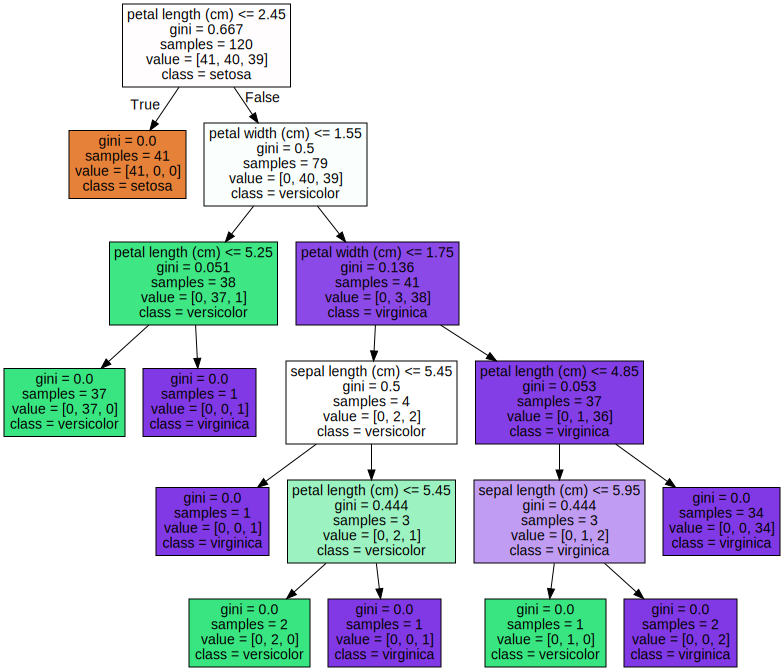

In [4]:
import graphviz
## 위에서 생성한 tree.dot 파일을 Graphviz가 읽어서 주피터 노트북상에서 시각화한다
with open("tree.dot") as f:
  dot_graph = f.read()
graphviz.Source(dot_graph)



*   더 이상 자식 노드가 없는 노드는 리프 노드이다. 리프 노드는 최종 클래스(레이블) 값이 결정되는 노드로, 리프 노드가 되려면 오직 하나의 클래스 값으로 최종 데이터가 구성되거나 리프 노드가 될 수 있는 하이퍼 파라미터 조건을 충족하면 된다. 자식 노드가 있는 노드는 브랜치 노드이며 자식 노드를 만들기 위한 분할 규칙 조건(e.g. petal length(cm) <=2.45)을 가지고 있다.

위의 노드 내에 기술된 지표들을 살펴보면, petal length(cm) <= 2.45와 같이 피처의 조건이 있는 것은 자식 노드를 만들기 위한 규칙 조건이다. 이 조건이 없으면 리프 노드이다. gini는 다음의 value=[]로 주어진 데이터 분포에서의 지니 계수이다. samples는 현 규칙에 해당하는 데이터 건수이다. value=[]는 클래스 값 기반의 데이터 건수이다. 붓꽃 데이터 세트는 클래스 값으로 0, 1, 2를 가지고 있으며 0: Setosa, 1: Versicolor, 2: Virginica 품종을 가리킨다.

루프 노드인 1번 지표에 대해서 더 알아본다. samples = 120개는 전체 데이터가 120개라는 의미이다. value=[41, 40, 39]는 Setosa 41개, Versicolor 40개, Virginica 39개로 데이터가 구성되어 있음을 말한다. sample 120개가 value=[41, 40, 39] 분포도로 되어 있으므로 지니 계수는 0.667이다. petal length (cm) <= 2.45 규칙으로 자식 노드를 생성한다. class = setosa는 하위 노드를 가질 경우에 setosa 개수가 41개로 제일 많다는 의미이다.

petal length (cm) <= 2.45 규칙이 True 또는 False로 분기하게 되면, 2번, 3번 노드가 만들어진다. 2번 노드는 모든 데이터가 Setosa로 결정되므로 클래스가 결정된 리프 노드가 되고, 더 이상 2번 노드에서 규칙을 만들 필요가 없다. 즉, 2번 노드는 petal length (cm) <= 2.45가 True인 규칙으로 생성되는 리프 노드이며, 그 의미는 (i) 41개의 샘플 데이터 모두 Setosa이므로 예측 클래스는 Setosa로 결정된다 (ii) 지니 계수는 0이다.

3번 노드는 Petal length (cm) <= 2.45가 False인 규칙 노드이다. 79개의 샘플 데이터 중 Versicolor 40개, Virginica 39개로 여전히 지니 계수는 0.5로 높으므로 다음 자식 브랜치 노드로 분기할 규칙이 필요하다. petal width (cm) <= 1.55 규칙으로 자식 노드를 생성한다.

각 노드의 색깔은 붓꽃 데이터의 레이블 값을 의미한다. 주황색은 0: Setosa, 초록색은 1: Versicolor, 보라색은 2: Virginica 레이블을 나타낸다. 색깔이 짙어질수록 지니 계수가 낮고 해당 레이블에 속하는 샘플 데이터가 많다는 의미이다.



*   이처럼 결정 트리는 규칙 생성 로직을 미리 제어하지 앟으면 완벽하게 클래스 값을 구별해내기 위해 트리 노드를 계속해서 만들어 간다. 이로 인해 결국 매우 복잡한 규칙 트리가 만들어져 모델이 쉽게 과적합되는 문제점을 가지게 된다. 결정 트리는 이러한 이유로 과적합이 상당히 높은 ML 알고리즘이다. 이 때문에 결정 트리 알고리즘을 제어하는 대부분의 하이퍼 파라미터는 복잡한 트리가 생성되는 것을 막기 위한 용도이다.
*   max_depth는 결정 트리의 최대 트리 깊이를 제어하며, 이를 조정하면(e.g. 제한 없음에서 3개로 설정한다) 트리 깊이가 설정된 max_depth에 따라 줄어들면서 더 간단한 결정 트리가 된다.
*   min_samples_split는 자식 규칙 노드를 분할해 만들기 위한 최소한의 샘플 데이터 개수이다. 이를 설정하면(e.g. min_samples_split=4) 자식 노드로 분할하려면 필요한 최소한의 샘플 개수에 미달할 경우에 더 이상 자식 규칙 노드를 위한 분할을 실행하지 않고 리프 노드를 만든다. 자연스럽게 트리 깊이도 줄고 더욱 더 간결한 결정 트리가 만들어진다.
*   더 이상 분할될 수 없는 리프 노드는 클래스 결정 값이 되는데, min_samples_leaf는 분할될 경우 왼쪽과 오른쪽 자식 노드 각각이 가지게 될 최소 데이터 건수를 지정한다. 즉, 어떤 노드가 분할할 경우 왼쪽과 오른쪽 자식 노드 중에 하나라도 min_samples_leaf로 지정된 최소 데이터 건수보다 더 작은 샘플 데이터 건수를 갖게 된다면, 해당 노드는 더 이상 분할하지 않고 리프 노드가 된다. min_samples_leaf의 값을 키우면 분할될 수 있는 조건이 어렵게 되므로, 리프 노드가 될 수 있는 조건이 상대적으로 완화된다. 보통 분할을 하게 되면 왼쪽, 오른쪽 자식 노드들은 어느 한 쪽의 샘플 데이터 건수는 크고, 다른 쪽의 샘플 데이터 건수는 작아지기 쉬운데, min_samples_leaf를 큰 값으로 지정하면 분할될 때 자식 노드들 모두가 해당 조건을 만족하기에 어려운 조건이 되기 때문이다.







*   결정 트리는 균일도에 기반해 어떠한 속성을 규칙 조건으로 선택하느냐가 중요한 요건이다. 중요한 몇 개의 피처가 명확한 규칙 트리를 만드는 데 크게 기여하며, 모델을 좀 더 간결하고 이상치에 강한 모델로 만들 수 있기 때문이다. 사이킷런은 결정 트리 알고리즘이 학습을 통해 규칙을 정하는 데 있어 피처의 중요한 역할 지표를 DecisionTreeClassifier 객체의 feature_importances_ 속성으로 제공한다. **feature_importances_**는 ndarray 형태로 값을 반환하며 피처 순서대로 값이 할당된다. (e.g. feature_importances_가 [0.01667014 0.02500521 0.03200643 0.92631822]라면 첫 번째 피처의 피처 중요도가 0.01667014, 두 번째 피처는 0.02500521와 같이 매치된다.) feature_importances_는 피처가 트리 분할 시 정보 이득이나 지니 계수를 얼마나 효율적으로 잘 개선시켰는지를 정규화된 값으로 표현한 것이다. 예외사항이 있지만, 일반적으로 값이 높을수록 해당 피처의 중요도가 높다는 의미이다.
*   항목 추가



Feature importances: 
[0.025 0.    0.555 0.42 ]
sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


<Axes: >

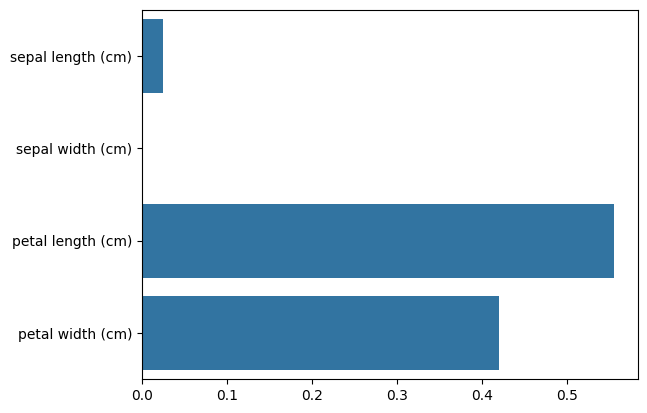

In [6]:
import seaborn as sns
import numpy as np
%matplotlib inline

## feature importance를 추출한다
print("Feature importances: \n{0}".format(np.round(dt_clf.feature_importances_, 3)))

## feature별 importance를 매핑한다
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
  print('{0} : {1:.3f}'.format(name, value))

## feature importance를 column 별로 시각화한다
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

### 결정 트리 과적합(Overfitting)



*   사이킷런은 분류를 위한 테스트용 데이터를 쉽게 만들 수 있도록 **make_classification() 함수**를 제공한다. make_classification()  호출 시 반환되는 객체는 피처 데이터 세트와 클래스 레이블 데이터 세트이다.



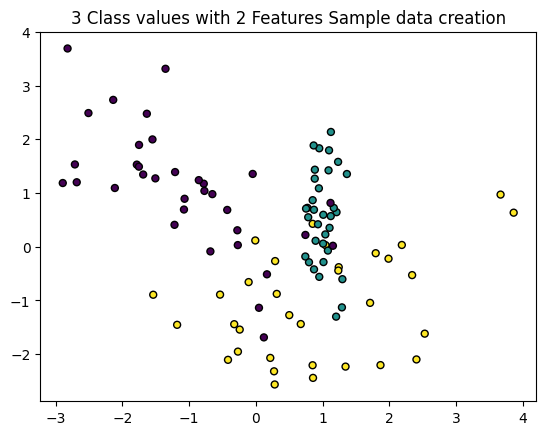

In [7]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data creation") ## 2개 피처가 3가지 유형의 클래스 값을 가지는 데이터 세트를 만들고 이를 그래프 형태로 시각화한다

## 2차원 시각화를 위해서 피처는 2개, 클래스는 3가지 유형의 분류 샘플 데이터를 생성한다
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                                           n_classes=3, n_clusters_per_class=1, random_state=0)

## 그래프 형태로 2개의 피처로 2차원 좌표를 시각화한다. 각 클래스 값은 다른 색깔로 표시된다
plt.scatter(X_features[:, 0], X_features[:, 1], marker='o', c=y_labels, s=25, edgecolor='k')

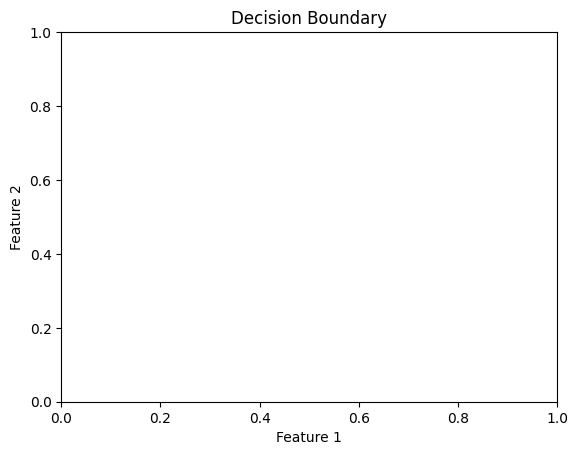

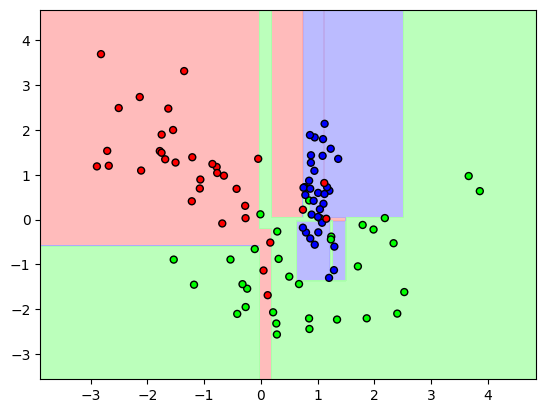

In [23]:
from sklearn.tree import DecisionTreeClassifier

## 특정한 트리 생성 제약 없는 결정 트리를 학습시키고 결정 경계를 시각화한다
dt_clf = DecisionTreeClassifier(random_state=156).fit(X_features, y_labels)  ## X_features와 y_labels 데이터 세트를 기반으로 결정 트리를 학습한다
## 첫 번째 학습 시에는 결정 트리 생성에 별다른 제약이 없도록 결정 트리의 하이퍼 파라미터를 디폴트로 한다

## 머신러닝 모델이 클래스 값을 예측하는 결정 기준을 색상과 경계로 나타내는 별도의 함수(유틸리티 함수)를 생성한다
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def visualize_boundary(model, X, y):
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF', '#AAFFAA'])
  cmap_bold = ListedColormap(['#FF0000', '#0000FF', '#00FF00'])
  plt.figure()
  plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, s=25, edgecolor='k')
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

visualize_boundary(dt_clf, X_features, y_labels)

일부 이상치 데이터까지 분류하기 위해 분할이 자주 일어나서 결정 기준 경계가 매우 많아졌음을 알 수 있다.


*   결정 트리의 기본 하이퍼 파라미터 설정은 리프 노드 안에 데이터가 모두 균일하거나 하나만 존재해야 하는 엄격한 분할 기준으로 인해 결정 기준 경계가 많아지고 복잡해진다. *이렇게 복잡한 모델은 학습 데이터 세트의 특성과 약간만 다른 형태의 데이터 세트를 예측하면 예측 정확도가 떨어지게 된다.*




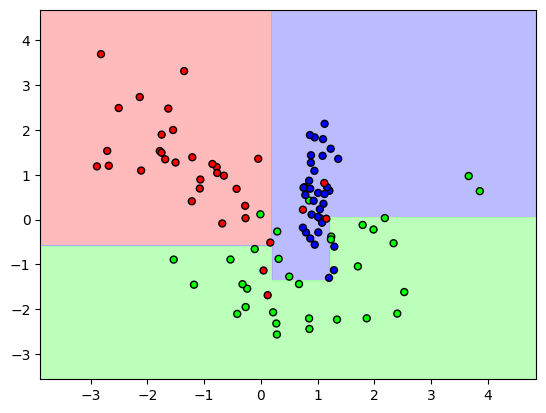

In [24]:
## min_samples_leaf=6으로 트리 생성 조건을 제약한 결정 경계를 시각환다
dt_clf = DecisionTreeClassifier(min_samples_leaf=6, random_state=156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

### 결정 트리 실습 - 사용자 행동 인식 데이터 세트

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## features.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 있다. 이를 DataFrame으로 로드한다
feature_name_df = pd.read_csv('/content/features.txt', sep='\s+',
                              header=None, names=['column_index', 'column_name'])

## 피처명 index를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출한다
feature_name = feature_name_df.iloc[:, 1].values.tolist()
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


피처명을 보면 인체의 움직임과 관련된 속성의 평균/표준편차가 X, Y, Z축 값으로 돼 있음을 유추할 수 있다.


*   피처명을 가지는 DataFrame을 이용해 데이터 파일을 데이터 세트 DataFrame에 로딩하기 전에 유의해야 할 부분은, 중복된 피처명을 가지고 있는 경우이다.  이 중복된 피처명들을 이용해 데이터 파일을 데이터 세트 DataFrame에 로드하면 오류가 발생한다. 중복된 피처명에 대해서는 원본 피처명에 _1 또는 _2를 추가로 부여해 변경한 뒤에 이를 이용해 데이터를 DataFrame에 로드할 수 있다.




In [27]:
## 중복된 피처명이 데이터 파일에 얼마나 있는지 알아본다
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index']>1].count())
feature_dup_df[feature_dup_df['column_index']>1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [34]:
## 중복된 피처명에 대해 원본 피처명에 _1 또는 _2를 추가로 부여해 새로운 피처명을 가지는 DataFrame을 반환하는 함수를 생성한다
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
  feature_dup_df = feature_dup_df.reset_index()
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1])
  if x[1]>0 else x[0], axis=1)
  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

In [35]:
import pandas as pd

def get_human_dataset():

  ## 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당한다
  feature_name_df = pd.read_csv('/content/features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])

  ## 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용해 신규 피처명 DataFrame을 생성한다
  new_feature_name_df = get_new_feature_name_df(feature_name_df)

  ## DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환한다
  feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

  ## 학습 피처 데이터세트와 테스트 피처 데이터를 DataFrame으로 로딩한다.
  X_train = pd.read_csv('/content/X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('/content/X_test.txt', sep='\s+', names=feature_name)

  ## 학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩한다
  y_train = pd.read_csv('/content/y_train.txt', sep='\s+', header=None, names=['action'])
  y_test = pd.read_csv('/content/y_test.txt', sep='\s+', header=None, names=['action'])

  ## 로드된 학습/테스트용 DataFrame을 모두 반환한다
  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

In [36]:
## 로드한 학습용 피처 데이터 세트를 간략히 살펴본다
print('## 학습 피처 데이터셋 info()')
print(X_train.info())

## 학습 피처 데이터셋 info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


학습 데이터 세트는 7352개의 레코드로 561개의 피처를 가지고 있다. 피처가 전부 float 형의 숫자 형이므로 별도의 카테고리 인코딩을 수행할 필요는 없다.

In [37]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


레이블 값은 1, 2, 3, 4, 5, 6의 6개 값이고 분포도는 특정 값으로 왜곡되지 않고 비교적 고르게 분포되어 있다.

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
## DecisionTreeClassifier을 통해 동작 예측 분류를 수행한다
## 이 때 DecisionTreeClassifier의 하이퍼 파라미터는 모두 디폴트 값으로 설정해 수행한다

## 예제 반복 시마다 동일한 예측 결과 도출을 위해 random_state를 설정한다
dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

## DecisionTreeClassifier의 하이퍼 파라미터를 추출한다
print('DecisionTreeClassifier 기본 하이퍼 파라미터: \n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터: 
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


In [41]:
from sklearn.model_selection import GridSearchCV
## 결정 트리의 Tree Depth가 예측 정확도에 주는 영향을 살펴본다

params = {
    'max_depth' : [6, 8, 10, 12, 16, 20, 24],
    'min_samples_split' : [16]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0: .4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치:  0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


max_depth가 8일 때 5개의 폴드 세트의 최고 평균 정확도 수치는 약 85.49%로 도출되었다.

In [43]:
## 5개의 CV 세트에서 max_depth 값의 증가에 따라 예측 성능이 어떻게 변했는지 cv_results_ 속성을 통해 살펴본다
## GridSearchCV 객체의 cv_results_ 속성을 DataFrame으로 생성한다
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

## max_depth 파라미터 값과 그 때의 테스트 세트, 학습 데이터 세트의 정확도 수치를 추출한다
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


mean_test_score은 max_depth가 8일 때 0.854로 정확도가 정점이고, 이를 넘어가면서 정확도는 계속 떨어진다.

In [44]:
max_depths = [6, 8, 10, 12, 16, 20, 24]
## max_depth 값을 변화시키면서 그때마다 학습과 테스트 세트에서의 예측 성능을 측정한다
for depth in max_depths:
  dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split=16, random_state=156)
  dt_clf.fit(X_train, y_train)
  pred = dt_clf.predict(X_test)
  accuracy = accuracy_score(y_test, pred)
  print('max_depth = {0} 정확도: {1: .4f}'.format(depth, accuracy))

max_depth = 6 정확도:  0.8551
max_depth = 8 정확도:  0.8717
max_depth = 10 정확도:  0.8599
max_depth = 12 정확도:  0.8571
max_depth = 16 정확도:  0.8599
max_depth = 20 정확도:  0.8565
max_depth = 24 정확도:  0.8565


min_samples_split=16으로 고정하고 max_depth의 변화에 따른 값을 측정했을 때, max_depth가 8일 경우 약 87.17%로 가장 높은 정확도가 나타났다. 그리고 max_depth가 8을 넘어가면서 정확도가 계속 감소하고 있다. (깊이가 깊어질수록 테스트 데이터 세트의 정확도는 더 떨어지므로, 하이퍼 파라미터를 이용해 깊이를 제어할 수 있어야 한다.)

In [45]:
## max_depth와 min_samples_split을 같이 변경하면서 정확도 성능을 튜닝한다
params = {
    'max_depth' : [8, 12, 16, 20],
    'min_samples_split' : [16, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0: .4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치:  0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


max_depth가 8, min_samples_split가 16일 때 약 85.49%의 최고 정확도가 나타난다.

In [46]:
## best_estimator_을 이용해 테스트 데이터 세트에 예측을 수행한다
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.8717


max_depth가 8, min_samples_split가 16일 때 약 87.17%의 테스트 데이터 세트 예측 정확도가 나타난다.

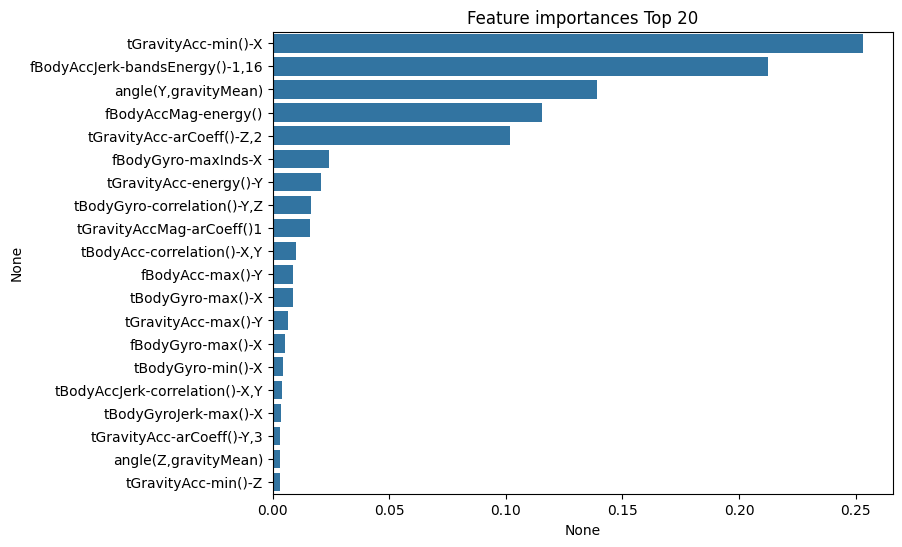

In [49]:
import seaborn as sns
## 결정 트리에서 각 피처의 중요도를 feature_importances_ 속성을 이용해 알아본다

ftr_importances_values = best_df_clf.feature_importances_
## Top 중요도로 정렬을 쉽게 하고, 시본의 막대그래프로 쉽게 표현하기 위해 Series 변환을 수행한다
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
## 중요도값 순으로 Series를 정렬한다
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

이 중 가장 높은 중요도를 가진 Top 5의 피처들이 매우 중요하게 규칙 생성에 영향을 미치고 있는 것을 알 수 있다.